In [ ]:
!pip install --upgrade transformers datasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.6/221.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.3/377.3 kB 32.3 MB/s eta 0:00:00


In [ ]:
!pip install transformers datasets torch imbalanced-learn scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 8.9 MB/s eta 0:00:00


In [ ]:
!pip install imbalanced-learn scikit-learn pandas numpy nltk


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Check where your file is located inside Google Drive
!ls "/content/drive/MyDrive"

# 👇 If you uploaded it inside a subfolder, adjust the path accordingly below
# Example: /content/drive/MyDrive/Datasets/pricerunner_aggragrate.csv


 code.gdoc
'Colab Notebooks'
 Cv
'Google AI Studio'
'linkedin Confessions .gdoc'
 models.zip
 pricerunner_aggregate.csv
 product_classification
 Resume.gdoc
'Saved from the Google app'
'sih brainstorm.gdoc'
 TFIDF_SMOTE_Splits
'Untitled document (10).gdoc'
'Untitled document (11).gdoc'
'Untitled document (12).gdoc'
'Untitled document (13).gdoc'
'Untitled document (14).gdoc'
'Untitled document (15).gdoc'
'Untitled document (16).gdoc'
'Untitled document (17).gdoc'
'Untitled document (18).gdoc'
'Untitled document (19).gdoc'
'Untitled document (1).gdoc'
'Untitled document (20).gdoc'
'Untitled document (2).gdoc'
'Untitled document (3).gdoc'
'Untitled document (4).gdoc'
'Untitled document (5).gdoc'
'Untitled document (6).gdoc'
'Untitled document (7).gdoc'
'Untitled document (8).gdoc'
'Untitled document (9).gdoc'
'Untitled document.gdoc'
'Untitled Jam (1).pdf'
'Untitled Jam.pdf'
'Untitled presentation.gslides'
'Untitled video - Made with Clipchamp (3).mp4'
'When it comes to maintenance strate

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/pricerunner_aggregate.csv')
print("🧾 Columns in your dataset:\n")
print(df.columns.tolist())


🧾 Columns in your dataset:

['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID', ' Category Label']


In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv('/content/drive/MyDrive/pricerunner_aggregate.csv')

# Remove unwanted spaces in column names
df.columns = df.columns.str.strip()

# Keep only relevant columns
df = df[['Product Title', 'Category Label']]

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("\n📊 Category distribution:")
print(df['Category Label'].value_counts())


✅ Dataset loaded successfully!
Shape: (35311, 2)

📊 Category distribution:
Category Label
Fridge Freezers     5501
Mobile Phones       4081
Washing Machines    4044
CPUs                3862
Fridges             3584
TVs                 3564
Dishwashers         3424
Digital Cameras     2697
Microwaves          2342
Freezers            2212
Name: count, dtype: int64


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)  # remove special characters
    return text

df['Product Title'] = df['Product Title'].astype(str).apply(clean_text)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['Product Title'])
y = df['Category Label']

print("✅ TF-IDF shape:", X.shape)


✅ TF-IDF shape: (35311, 5000)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("\n✅ Before SMOTE:", X.shape, "→ After SMOTE:", X_smote.shape)
print("\n📊 Category distribution (After SMOTE):")
print(pd.Series(y_smote).value_counts())



✅ Before SMOTE: (35311, 5000) → After SMOTE: (55010, 5000)

📊 Category distribution (After SMOTE):
Category Label
Mobile Phones       5501
TVs                 5501
CPUs                5501
Digital Cameras     5501
Microwaves          5501
Dishwashers         5501
Washing Machines    5501
Freezers            5501
Fridge Freezers     5501
Fridges             5501
Name: count, dtype: int64


In [ ]:
# Create a balanced text dataset using oversampling logic
balanced_df = df.groupby('Category Label', group_keys=False).apply(
    lambda x: x.sample(pd.Series(y_smote).value_counts().max(), replace=True, random_state=42)
).reset_index(drop=True)

print("\n✅ Balanced text dataset shape:", balanced_df.shape)
print("\n📊 Category distribution (Balanced text):")
print(balanced_df['Category Label'].value_counts())



✅ Balanced text dataset shape: (55010, 2)

📊 Category distribution (Balanced text):
Category Label
CPUs                5501
Digital Cameras     5501
Dishwashers         5501
Freezers            5501
Fridge Freezers     5501
Fridges             5501
Microwaves          5501
Mobile Phones       5501
TVs                 5501
Washing Machines    5501
Name: count, dtype: int64


/tmp/ipython-input-1682898460.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('Category Label', group_keys=False).apply(


In [ ]:
from sklearn.model_selection import train_test_split

# Unbalanced split (for DistilBERT base model)
train_unbal, test_unbal = train_test_split(
    df, test_size=0.2, stratify=df['Category Label'], random_state=42)

# Balanced split (for DistilBERT + SMOTE model)
train_bal, test_bal = train_test_split(
    balanced_df, test_size=0.2, stratify=balanced_df['Category Label'], random_state=42)

print("\n🧩 Split summary:")
print("Unbalanced train:", train_unbal.shape, "| test:", test_unbal.shape)
print("Balanced train:", train_bal.shape, "| test:", test_bal.shape)



🧩 Split summary:
Unbalanced train: (28248, 2) | test: (7063, 2)
Balanced train: (44008, 2) | test: (11002, 2)


In [ ]:
train_unbal.to_csv('train_unbalanced.csv', index=False)
test_unbal.to_csv('test_unbalanced.csv', index=False)
train_bal.to_csv('train_balanced.csv', index=False)
test_bal.to_csv('test_balanced.csv', index=False)

print("✅ CSVs saved locally!")


✅ CSVs saved locally!


In [ ]:
import shutil

drive_path = '/content/drive/MyDrive/TFIDF_SMOTE_Splits/'
!mkdir -p "$drive_path"

for f in ['train_unbalanced.csv', 'test_unbalanced.csv', 'train_balanced.csv', 'test_balanced.csv']:
    shutil.copy(f, drive_path)

print("\n✅ All 4 files saved to Google Drive folder:")
print(drive_path)

!ls -lh *.csv



✅ All 4 files saved to Google Drive folder:
/content/drive/MyDrive/TFIDF_SMOTE_Splits/
-rw-r--r-- 1 root root 695K Nov  9 16:01 test_balanced.csv
-rw-r--r-- 1 root root 451K Nov  9 16:01 test_unbalanced.csv
-rw-r--r-- 1 root root 2.8M Nov  9 16:01 train_balanced.csv
-rw-r--r-- 1 root root 1.8M Nov  9 16:01 train_unbalanced.csv


In [ ]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn


In [ ]:
import pandas as pd

# Load datasets
train_unbal = pd.read_csv('/content/drive/MyDrive/TFIDF_SMOTE_Splits/train_unbalanced.csv')
test_unbal = pd.read_csv('/content/drive/MyDrive/TFIDF_SMOTE_Splits/test_unbalanced.csv')
train_bal = pd.read_csv('/content/drive/MyDrive/TFIDF_SMOTE_Splits/train_balanced.csv')
test_bal = pd.read_csv('/content/drive/MyDrive/TFIDF_SMOTE_Splits/test_balanced.csv')

print("✅ Files loaded successfully!")
print("Unbalanced train:", train_unbal.shape, "test:", test_unbal.shape)
print("Balanced train:", train_bal.shape, "test:", test_bal.shape)


✅ Files loaded successfully!
Unbalanced train: (28248, 2) test: (7063, 2)
Balanced train: (44008, 2) test: (11002, 2)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_unbal['label'] = le.fit_transform(train_unbal['Category Label'])
test_unbal['label'] = le.transform(test_unbal['Category Label'])
train_bal['label'] = le.fit_transform(train_bal['Category Label'])
test_bal['label'] = le.transform(test_bal['Category Label'])

num_labels = len(le.classes_)
print("📦 Number of categories:", num_labels)


📦 Number of categories: 10


In [ ]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(batch['Product Title'], padding='max_length', truncation=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch_xla/experimental/gru.py:113: SyntaxWarning: invalid escape sequence '\_'
  * **h_n**: tensor of shape :math:`(D * \text{num\_layers}, H_{out})` or


In [ ]:
from datasets import Dataset

train_ds_unbal = Dataset.from_pandas(train_unbal[['Product Title', 'label']])
test_ds_unbal = Dataset.from_pandas(test_unbal[['Product Title', 'label']])
train_ds_bal = Dataset.from_pandas(train_bal[['Product Title', 'label']])
test_ds_bal = Dataset.from_pandas(test_bal[['Product Title', 'label']])

train_ds_unbal = train_ds_unbal.map(tokenize, batched=True)
test_ds_unbal = test_ds_unbal.map(tokenize, batched=True)
train_ds_bal = train_ds_bal.map(tokenize, batched=True)
test_ds_bal = test_ds_bal.map(tokenize, batched=True)

train_ds_unbal.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_unbal.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
train_ds_bal.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_bal.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/28248 [00:00<?, ? examples/s]

Map:   0%|          | 0/7063 [00:00<?, ? examples/s]

Map:   0%|          | 0/44008 [00:00<?, ? examples/s]

Map:   0%|          | 0/11002 [00:00<?, ? examples/s]

In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import torch
from transformers.trainer_utils import IntervalStrategy # Import IntervalStrategy

def train_and_evaluate(train_ds, test_ds, label_name):
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=num_labels
    )

    training_args = TrainingArguments(
        output_dir=f'./results_{label_name}',
        evaluation_strategy=IntervalStrategy.EPOCH, # Use IntervalStrategy.EPOCH
        save_strategy=IntervalStrategy.EPOCH,             # save best checkpoint each epoch
        load_best_model_at_end=True,       # restore best model
        metric_for_best_model="eval_loss", # decide best model by lowest eval loss
        greater_is_better=False,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,                # we can train up to 5, but stop early
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=100,
        report_to="none",
        save_total_limit=2
    )

    # Early stopping after 2 epochs without improvement
    early_stop = EarlyStoppingCallback(early_stopping_patience=2)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        callbacks=[early_stop]
    )

    trainer.train()

    # Evaluate
    preds = trainer.predict(test_ds)
    y_pred = preds.predictions.argmax(-1)
    y_true = preds.label_ids

    return y_true, y_pred

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
import transformers
print(transformers.__version__)


4.57.1


In [ ]:
!pip install --upgrade transformers datasets


In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch

def train_and_evaluate_safe(train_ds, test_ds, label_name, num_epochs=3):
    """
    Version-safe DistilBERT training function for Transformers < 4.30.
    """
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=num_labels
    )

    # Version-safe TrainingArguments
    training_args = TrainingArguments(
        output_dir=f'./results_{label_name}',
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=num_epochs,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=50,
        do_train=True,
        do_eval=True,
        report_to="none",
        optim='adamw_torch',
        fp16=False, # Explicitly disable fp16
        bf16=False  # Explicitly disable bf16
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds
    )

    trainer.train()

    # Predictions
    preds = trainer.predict(test_ds)
    y_pred = preds.predictions.argmax(-1)
    y_true = preds.label_ids

    return y_true, y_pred, trainer


📊 Results for DistilBERT - Unbalanced
Accuracy : 0.990
Macro F1 : 0.990
Macro Precision : 0.990
Macro Recall : 0.989


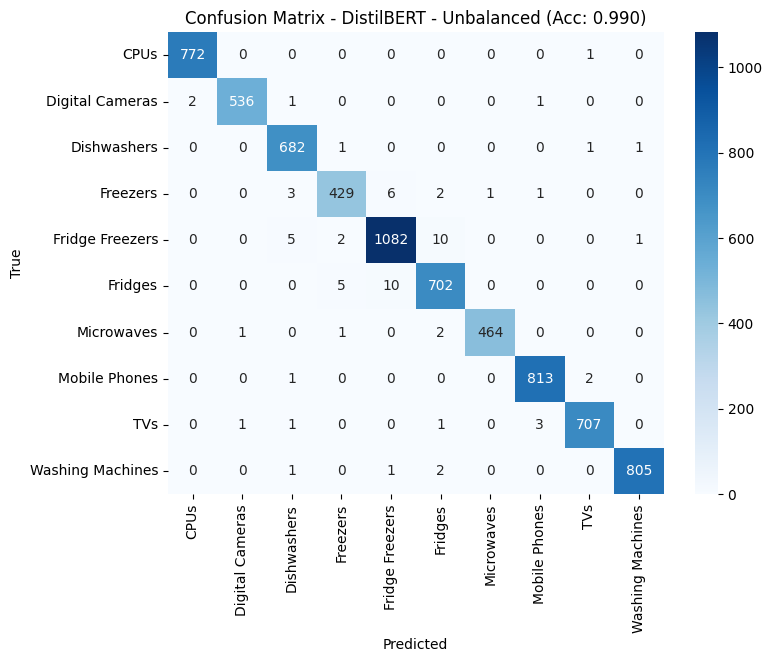


📊 Results for DistilBERT + SMOTE (Balanced)
Accuracy : 0.996
Macro F1 : 0.996
Macro Precision : 0.996
Macro Recall : 0.996


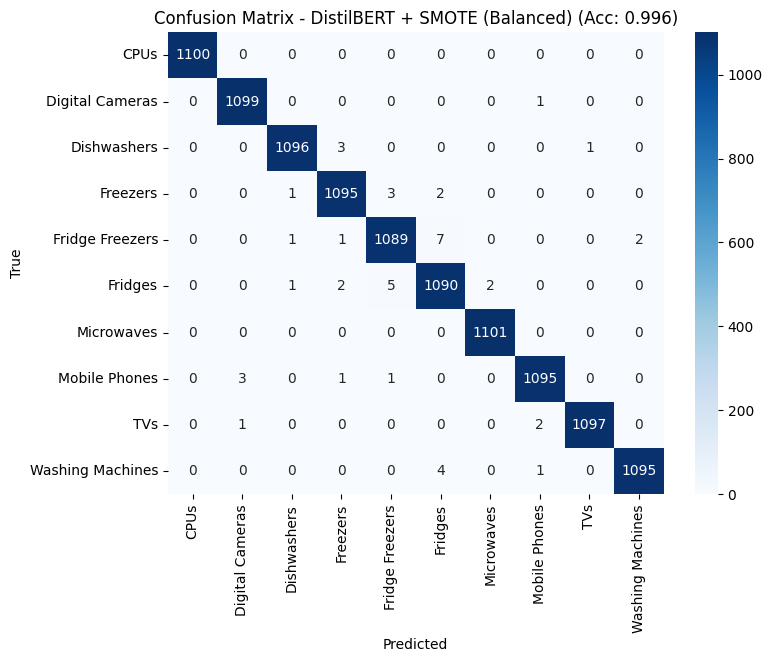

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_results_safe(y_true, y_pred, title):
    """
    Compute metrics and plot confusion matrix.
    """
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')

    print(f"\n📊 Results for {title}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Macro F1 : {f1:.3f}")
    print(f"Macro Precision : {precision:.3f}")
    print(f"Macro Recall : {recall:.3f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {title} (Acc: {acc:.3f})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# Evaluate both models
metrics_unbal = evaluate_results_safe(y_true_unbal, y_pred_unbal, "DistilBERT - Unbalanced")
metrics_bal = evaluate_results_safe(y_true_bal, y_pred_bal, "DistilBERT + SMOTE (Balanced)")


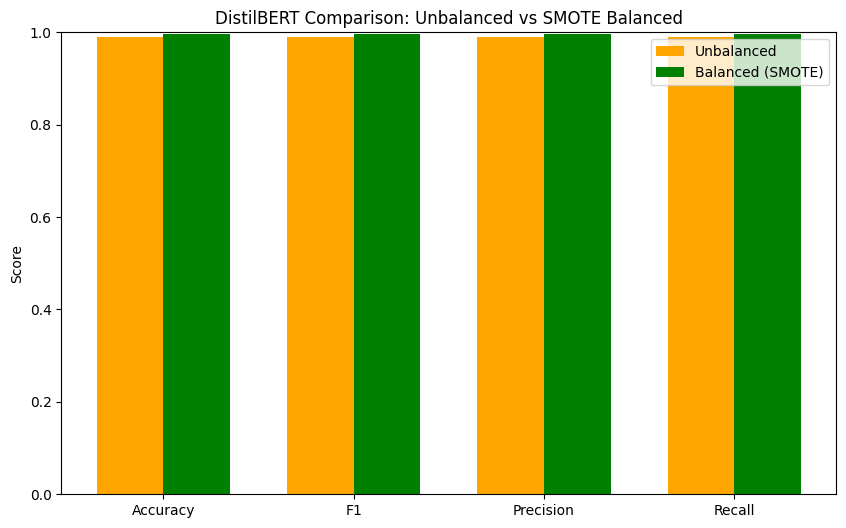

In [ ]:
import numpy as np

metrics = ['accuracy', 'f1', 'precision', 'recall']
unbal_vals = [metrics_unbal[m] for m in metrics]
bal_vals = [metrics_bal[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, unbal_vals, width, label='Unbalanced', color='orange')
plt.bar(x + width/2, bal_vals, width, label='Balanced (SMOTE)', color='green')

plt.ylabel('Score')
plt.ylim(0,1)
plt.title('DistilBERT Comparison: Unbalanced vs SMOTE Balanced')
plt.xticks(x, [m.capitalize() for m in metrics])
plt.legend()
plt.show()
